# Qwen Subjectivity Classification Evaluation

Evaluate whether models can distinguish **objective** from **subjective** sentences in academic peer-review sections.

**Pipeline:**
1. Use sentences from `/data/test_dataset.csv`
2. Run each through Qwen Model locally via **Ollama**
3. Collect structured output: `label`, `confidence`, `reasoning`, `explanation`
4. Analyse model performance

---
### Setup: Ollama (macOS)
```bash
# Install Ollama (macOS)
brew install ollama
# or: curl -fsSL https://ollama.com/install.sh | sh

# Start the server
ollama serve

# Pull the model (one-time, ~5 GB)
ollama pull qwen3:8b
```

In [ ]:
import json
import time
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from openai import OpenAI
from IPython.display import display, HTML

OLLAMA_BASE_URL = "http://localhost:11434/v1"
MODELS = ["qwen3:1.7b", "qwen3:8b", "qwen3:14b"]
CSV_PATH = Path("./data/test_dataset.csv")
SAMPLE_N = 100
RANDOM_SEED = 42
REQUEST_DELAY = 0.3

client = OpenAI(
    base_url = OLLAMA_BASE_URL,
    api_key = "ollama",
)

## 1. Verify Ollama is Running

In [ ]:
import urllib.request, urllib.error

def check_ollama():
    try:
        with urllib.request.urlopen("http://localhost:11434", timeout=3) as r:
            print(f"Ollama is running  (status {r.status})")
            return True
    except Exception as e:
        print(f"Ollama NOT reachable: {e}")
        print("Start it with: ollama serve")
        return False

def check_model(model: str):
    try:
        models = client.models.list()
        names = [m.id for m in models.data]
        if model in names:
            print(f"  ✓  '{model}' is available")
            return True
        else:
            print(f"  ✗  '{model}' NOT found.  Pull it with: ollama pull {model}")
            print(f"     Available: {names}")
            return False
    except Exception as e:
        print(f"  Could not list models: {e}")
        return False

ollama_ok = check_ollama()
if ollama_ok:
    print("Checking models:")
    model_status = {m: check_model(m) for m in MODELS}
    ready = [m for m, ok in model_status.items() if ok]
    print(f"\nReady to evaluate: {ready}")

Ollama is running  (status 200)
Checking models:
  ✓  'qwen3:1.7b' is available
  ✓  'qwen3:8b' is available
  ✓  'qwen3:14b' is available

Ready to evaluate: ['qwen3:1.7b', 'qwen3:8b', 'qwen3:14b']


## 2. Import data

In [ ]:
df_full = pd.read_csv(CSV_PATH)
print(f"Total rows: {len(df_full)}")

df_sample = df_full.copy()
df_sample.index +=1

print(f"Sampled {len(df_sample)} sentences for evaluation")
df_sample[["paper_title", "reviewer", "sentence", "matched_markers"]].head(5)

Total rows: 100
Sampled 100 sentences for evaluation


,paper_title,reviewer,sentence,matched_markers
1,Reframing attention as a reinforcement learnin...,ICLR.cc/2026/Conference/Submission25201/Review...,"Some key symbols (e.g., $J^t$) are used before...",NaN
2,THE JPEG BLIND SPOT: EXPOSING A CRITICAL VULNE...,ICLR.cc/2026/Conference/Submission25466/Review...,Prior literature has extensively documented th...,NaN
3,DIANA with Compression for Distributed Variati...,ICLR.cc/2026/Conference/Submission25336/Review...,Error feedback is typically useful for biased ...,NaN
4,Curricular Adversarial Training for Robust Cod...,ICLR.cc/2026/Conference/Submission25575/Review...,Only high-level summaries are given—no impleme...,NaN
5,On the (In)Significance of Feature Selection i...,ICLR.cc/2026/Conference/Submission25529/Review...,The dataset selection process is not described.,NaN


## 3. Prompt Design

We ask the model to classify each sentence as **subjective** or **objective** and return a structured JSON with four fields:

| Field | Description |
|---|---|
| `label` | `"subjective"` or `"objective"` |
| `confidence` | float `0.0–1.0` |
| `reasoning` | step-by-step chain of thought |
| `explanation` | concise one-sentence justification |

In [ ]:
SYSTEM_PROMPT = """\
You are a computational linguistics expert specialising in opinion mining and subjectivity analysis.

Your task: classify a sentence from an academic peer review as either
SUBJECTIVE or OBJECTIVE.

Definitions
-----------
SUBJECTIVE – expresses opinions, beliefs, evaluations, hedges, or emotional stances of the author.
  Examples: personal judgements ("I think", "in my opinion"), evaluative language ("unclear",
  "impressive", "fails to"), hedging ("somewhat", "not convinced"), author-claim framing
  ("the paper claims").

OBJECTIVE – states verifiable facts, describes methods, reports results, or defines concepts
  without expressing the author's stance.
  Examples: numerical results, dataset descriptions, algorithm steps, citations.

Output format (strict JSON, no markdown fences):
{
  "label": "subjective" | "objective",
  "confidence": <float between 0.0 and 1.0>,
  "reasoning": "<step-by-step chain of thought>",
  "explanation": "<one concise sentence summarising the decision>"
}
"""

USER_TEMPLATE = """\
Sentence from a peer-review:
\"\"\"{sentence}\"\"\"

Classify this sentence and return the JSON object.
"""

print("Prompt template ready.")

Prompt template ready.


## 4. Run Inference

In [ ]:
def parse_json_output(raw: str) -> dict:
    """Extract JSON from model output, even if wrapped in markdown fences."""
    raw =re.sub(r"```(?:json)?\s*", "", raw).strip("`").strip()
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        m =re.search(r"\{[\s\S]+\}", raw)
        if m:
            return json.loads(m.group())
        return {"error": "parse_failed", "raw": raw}


def classify_sentence(sentence: str, model: str) -> dict:
    """Send one sentence to the given model and return parsed result."""
    user_msg =USER_TEMPLATE.format(sentence=sentence)
    try:
        response =client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": user_msg},
            ],
            temperature=0.0,
            response_format={"type": "json_object"},
        )
        raw =response.choices[0].message.content
        return parse_json_output(raw)
    except Exception as e:
        return {"error": str(e)}


def run_evaluation(model: str, df: pd.DataFrame) -> pd.DataFrame:
    """Run inference for every row in df using the given model. Returns a results DataFrame."""
    results =[]
    n =len(df)
    for i, row in df.iterrows():
        sentence =row["sentence"]
        print(f"  [{i:02d}/{n}] {sentence[:80]}{'...' if len(sentence) > 80 else ''}")

        result =classify_sentence(sentence, model)
        result["idx"] =   i
        result["sentence"]= sentence
        result["matched_markers"] =row["matched_markers"]
        result["paper_title"] =row["paper_title"]
        result["reviewer"]= row["reviewer"]
        result["ground_truth"]=row["label"]
        result["model"] =  model
        results.append(result)

        if "label" in result:
            print(f"    → {result['label'].upper()}  (confidence {result.get('confidence', '?'):.2f})")
        else:
            print(f"    → ERROR: {result.get('error', result)}")

        time.sleep(REQUEST_DELAY)

    df_out =pd.DataFrame(results)
    df_out["label"]= df_out["label"].str.lower().str.strip() if "label" in df_out.columns else "error"
    df_out["confidence"] =pd.to_numeric(df_out.get("confidence"), errors="coerce")
    df_out["ground_truth"] =df_out["ground_truth"].str.lower().str.strip()
    df_out["correct"]=df_out["label"] ==df_out["ground_truth"]
    return df_out


print("Functions defined. Ready to run inference.")


Functions defined. Ready to run inference.


In [20]:
out_dir =Path("results")
out_dir.mkdir(exist_ok=True)

all_results: dict[str, pd.DataFrame] ={}

for model in MODELS:
    print(f"\n{'='*65}")
    print(f"  Model: {model}")
    print(f"{'='*65}")

    df = run_evaluation(model, df_sample)
    all_results[model] =df

    model_slug =model.replace(":", "_").replace(".", "_")
    df.to_csv(out_dir / f"{model_slug}_results.csv", index=False)

    acc =df["correct"].mean()
    n_err =df["label"].isna().sum() + (df["label"] =="error").sum()
    print(f"\n  Done. Accuracy: {acc:.1%}  |  Parse errors: {n_err}  |  Saved → results/{model_slug}_results.csv")

print(f"\n{'='*65}")
print("All models evaluated.")



  Model: qwen3:1.7b
  [01/100] Some key symbols (e.g., $J^t$) are used before being defined, and sets $N$ and $...
    → SUBJECTIVE  (confidence 1.00)
  [02/100] Prior literature has extensively documented this phenomenon, and it's recognized...
    → OBJECTIVE  (confidence 0.95)
  [03/100] Error feedback is typically useful for biased but contractive compressors, but T...
    → SUBJECTIVE  (confidence 0.80)
  [04/100] Only high-level summaries are given—no implementation details, hyperparameters, ...
    → OBJECTIVE  (confidence 0.95)
  [05/100] The dataset selection process is not described.
    → OBJECTIVE  (confidence 0.99)
  [06/100] No justification is provided for defining exactly 42 evaluation dimensions in Se...
    → SUBJECTIVE  (confidence 0.95)
  [07/100] There's no ablation for particle‑per‑cell, interior/surface ratios, or grid reso...
    → OBJECTIVE  (confidence 0.95)
  [08/100] The approach assumes access to reasonably accurate PRMs, execution sandboxes, an...
    → O

## 5. Results DataFrame

In [ ]:
MODEL_TO_DISPLAY = MODELS[1]

df_results = all_results[MODEL_TO_DISPLAY]
print(f"Showing results for: {MODEL_TO_DISPLAY}  ({len(df_results)} rows)")

display_cols = ["idx", "label", "ground_truth", "confidence", "correct", "matched_markers", "explanation", "sentence"]
df_results[display_cols].head(10)

Showing results for: qwen3:8b  (100 rows)


,idx,label,ground_truth,confidence,correct,matched_markers,explanation,sentence
0,1,objective,objective,0.95,True,NaN,The statement presents verifiable factual clai...,"Some key symbols (e.g., $J^t$) are used before..."
1,2,objective,objective,0.95,True,NaN,The sentence primarily presents verifiable tec...,Prior literature has extensively documented th...
2,3,objective,objective,0.95,True,NaN,The sentence objectively identifies a specific...,Error feedback is typically useful for biased ...
3,4,objective,objective,0.95,True,NaN,The statement describes the paper's content co...,Only high-level summaries are given—no impleme...
4,5,objective,objective,0.95,True,NaN,The statement is an objective factual claim ab...,The dataset selection process is not described.
5,6,subjective,objective,0.95,False,NaN,The sentence combines factual observation with...,No justification is provided for defining exac...
6,7,objective,objective,0.95,True,NaN,The statement describes a verifiable factual o...,"There's no ablation for particle‑per‑cell, int..."
7,8,objective,objective,0.95,True,NaN,The statement presents verifiable claims about...,The approach assumes access to reasonably accu...
8,9,subjective,objective,0.95,False,NaN,The sentence criticizes the paper's lack of cl...,"What is a corridor constant, and what does it ..."
9,10,subjective,objective,0.95,False,NaN,The sentence expresses a subjective evaluation...,Core components like the Scenario Classifier a...


In [ ]:
summary =pd.DataFrame([
    {
        "model": m,
        "accuracy": df["correct"].mean(),
        "n_subjective": (df["label"] =="subjective").sum(),
        "n_objective": (df["label"] =="objective").sum(),
        "parse_errors": df["label"].isna().sum() + (df["label"] =="error").sum(),
        "avg_conf": df["confidence"].mean(),
    }
    for m, df in all_results.items()
])
summary["accuracy"] = summary["accuracy"].map("{:.1%}".format)
summary["avg_conf"] = summary["avg_conf"].map("{:.2f}".format)
display(summary)


,model,accuracy,n_subjective,n_objective,parse_errors,avg_conf
0,qwen3:1.7b,84.0%,58,42,0,0.94
1,qwen3:8b,88.0%,62,38,0,0.95
2,qwen3:14b,88.0%,58,42,0,0.94


## 6. Detailed Output – Label / Confidence / Reasoning / Explanation

In [29]:
for _, row in df_results.iterrows():
    label =row.get("label", "error")
    confidence =row.get("confidence")
    reasoning =row.get("reasoning", "N/A")
    explanation=row.get("explanation", "N/A")
    sentence =row.get("sentence", "")
    markers =row.get("matched_markers", "")
    correct =row.get("correct", False)
    tick ="✓" if correct else "✗"

    label_color ="#2ecc71" if label =="subjective" else "#e74c3c"
    border ="#2ecc71" if correct else "#e74c3c"

    conf_str =f"{confidence:.0%}" if pd.notna(confidence) else "—"

    html =f"""
    <div style="border-left:4px solid {border}; padding:8px 12px; margin:10px 0;
                font-family:monospace; font-size:13px; background:#fafafa;">
      <b>#{row['idx']}</b>&nbsp;
      <span style="background:{label_color}; color:#fff; border-radius:3px;
                   padding:1px 6px; margin-right:6px;">{label.upper()}</span>
      <span style="color:#555;">Confidence: <b>{conf_str}</b></span>
      <span style="float:right; font-size:16px;">{tick}</span><br/>
      <div style="margin:6px 0; color:#333;">"{sentence}"</div>
      <div style="color:#888; font-size:11px;">Markers: {markers}</div>
      <details style="margin-top:6px;">
        <summary style="cursor:pointer; color:#3498db;">Reasoning &amp; Explanation</summary>
        <div style="margin-top:4px; white-space:pre-wrap; color:#444;">
          <b>Reasoning:</b> {reasoning}<br/><br/>
          <b>Explanation:</b> {explanation}
        </div>
      </details>
    </div>
    """
    display(HTML(html))

## 7. Performance Summary

In [ ]:
print(f"{'Model':<20} {'Samples':>8} {'Correct':>8} {'Accuracy':>10} {'SubjPred':>10} {'ObjPred':>9} {'ParseErr':>9}")
print("-" * 80)
for model, df in all_results.items():
    n_total = len(df)
    n_correct = df["correct"].sum()
    accuracy = n_correct / n_total
    n_subj = (df["label"] =="subjective").sum()
    n_obj = (df["label"] =="objective").sum()
    n_errors = df["label"].isna().sum() + (df["label"] =="error").sum()
    print(f"{model:<20} {n_total:>8} {n_correct:>8} {accuracy:>10.1%} {n_subj:>10} {n_obj:>9} {n_errors:>9}")

print()
print("Ground-truth distribution (shared across runs):")
gt = ll_results[MODELS[0]]["ground_truth"].value_counts()
print(gt.to_string())

print()
print("Avg confidence per model:")
for model, df in all_results.items():
    subj_conf = df.loc[df["label"] =="subjective", "confidence"].mean()
    obj_conf = df.loc[df["label"] =="objective",  "confidence"].mean()
    print(f"  {model:<20}  subj={subj_conf:.2f}  obj={obj_conf:.2f}")

Model                 Samples  Correct   Accuracy   SubjPred   ObjPred  ParseErr
--------------------------------------------------------------------------------
qwen3:1.7b                100       84      84.0%         58        42         0
qwen3:8b                  100       88      88.0%         62        38         0
qwen3:14b                 100       88      88.0%         58        42         0

Ground-truth distribution (shared across runs):
ground_truth
objective     50
subjective    50

Avg confidence per model:
  qwen3:1.7b            subj=0.92  obj=0.96
  qwen3:8b              subj=0.95  obj=0.95
  qwen3:14b             subj=0.93  obj=0.95


In [ ]:
print("Subjective ground-truth breakdown (TP / FN → predicted objective):")
print(f"{'Model':<20} {'GT_Subj':>8} {'TP_Subj':>8} {'FN_Subj':>8} {'Recall':>8}")
print("-" * 60)
for model, df in all_results.items():
    gt_subj = df[df["ground_truth"] == "subjective"]
    tp_subj = (gt_subj["label"] == "subjective").sum()   # correctly predicted
    fn_subj = (gt_subj["label"] == "objective").sum()    # misclassified as objective
    recall  = tp_subj / len(gt_subj) if len(gt_subj) else float("nan")
    print(f"{model:<20} {len(gt_subj):>8} {tp_subj:>8} {fn_subj:>8} {recall:>8.1%}")

print()
print("Objective ground-truth breakdown (TN / FP → predicted subjective):")
print(f"{'Model':<20} {'GT_Obj':>8} {'TN_Obj':>8} {'FP_Obj':>8} {'Recall':>8}")
print("-" * 60)
for model, df in all_results.items():
    gt_obj = df[df["ground_truth"] == "objective"]
    tn_obj = (gt_obj["label"] == "objective").sum()     # correctly predicted
    fp_obj = (gt_obj["label"] == "subjective").sum()    # misclassified as subjective
    recall = tn_obj / len(gt_obj) if len(gt_obj) else float("nan")
    print(f"{model:<20} {len(gt_obj):>8} {tn_obj:>8} {fp_obj:>8} {recall:>8.1%}")


Subjective ground-truth breakdown (TP / FN → predicted objective):
Model                 GT_Subj  TP_Subj  FN_Subj   Recall
------------------------------------------------------------
qwen3:1.7b                 50       46        4    92.0%
qwen3:8b                   50       50        0   100.0%
qwen3:14b                  50       48        2    96.0%

Objective ground-truth breakdown (TN / FP → predicted subjective):
Model                  GT_Obj   TN_Obj   FP_Obj   Recall
------------------------------------------------------------
qwen3:1.7b                 50       38       12    76.0%
qwen3:8b                   50       38       12    76.0%
qwen3:14b                  50       40       10    80.0%


## 8. Visualisations

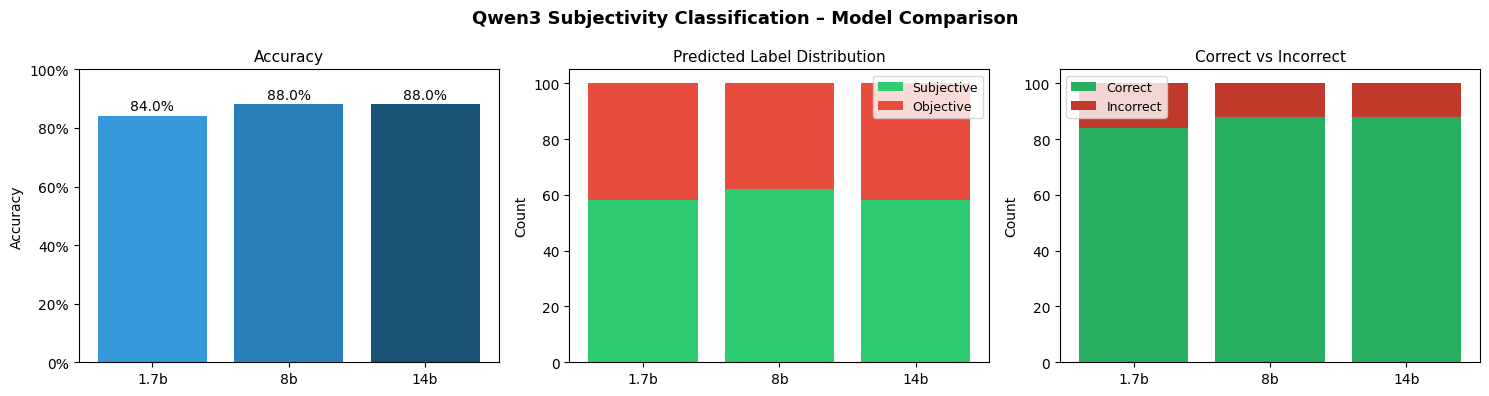

Saved: qwen3_comparison.png


In [ ]:
n_models =len(all_results)
fig, axes =plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Qwen3 Subjectivity Classification – Model Comparison",
             fontsize=13, fontweight="bold")

model_names=list(all_results.keys())
short_names=[m.replace("qwen3:", "") for m in model_names]
colors_subj=["#2ecc71", "#27ae60", "#1e8449"]
colors_obj =["#e74c3c", "#c0392b", "#922b21"]

ax = axes[0]
accuracies =[all_results[m]["correct"].mean() for m in model_names]
bars = ax.bar(short_names, accuracies, color=["#3498db", "#2980b9", "#1a5276"])
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Accuracy", fontsize=11)
ax.set_ylabel("Accuracy")
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=10)

ax = axes[1]
x =range(n_models)
n_subj =[( all_results[m]["label"] =="subjective").sum() for m in model_names]
n_obj=[( all_results[m]["label"] =="objective" ).sum() for m in model_names]
ax.bar(x, n_subj, label="Subjective", color="#2ecc71")
ax.bar(x, n_obj,  label="Objective",  color="#e74c3c", bottom=n_subj)
ax.set_xticks(list(x)); ax.set_xticklabels(short_names, fontsize=10)
ax.set_ylabel("Count"); ax.set_title("Predicted Label Distribution", fontsize=11)
ax.legend(fontsize=9)

ax = axes[2]
n_correct =[all_results[m]["correct"].sum()  for m in model_names]
n_incorrect =[len(all_results[m]) - c for m, c in zip(model_names, n_correct)]
ax.bar(x, n_correct,   label="Correct",   color="#27ae60")
ax.bar(x, n_incorrect, label="Incorrect", color="#c0392b", bottom=n_correct)
ax.set_xticks(list(x)); ax.set_xticklabels(short_names, fontsize=10)
ax.set_ylabel("Count"); ax.set_title("Correct vs Incorrect", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("qwen3_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: qwen3_comparison.png")

## 9. Misclassified Sentences

In [ ]:
misclassified = df_results[~df_results["correct"]].copy()
print(f"Misclassified: {len(misclassified)} / {n_total}")

if len(misclassified) > 0:
    for _, row in misclassified.iterrows():
        print(f"\n[#{row['idx']}] Predicted: {row['label'].upper()}  | Confidence: {row['confidence']:.0%}")
        print(f"Sentence: {row['sentence'][:200]}")
        print(f"Marker: {row['matched_markers']}")
        print(f"Explain: {row.get('explanation', 'N/A')}")
else:
    print("Perfect recall — no misclassifications!")

Misclassified: 12 / 100

[#6] Predicted: SUBJECTIVE  | Confidence: 95%
  Sentence : No justification is provided for defining exactly 42 evaluation dimensions in Section 3.2, lacking a basis for this specific number.
  Markers  : nan
  Explain  : The sentence combines factual observation with evaluative criticism, making it subjective.

[#9] Predicted: SUBJECTIVE  | Confidence: 95%
  Sentence : What is a corridor constant, and what does it mean to be explicit and falsifiable?
  Markers  : nan
  Explain  : The sentence criticizes the paper's lack of clarity on specific terms, which is a subjective assessment of its quality.

[#10] Predicted: SUBJECTIVE  | Confidence: 95%
  Sentence : Core components like the Scenario Classifier and Expert Router are critical to the framework, but Section 3.3 provides no detailed information about their design (e.g., model architecture of the class
  Markers  : nan
  Explain  : The sentence expresses a subjective evaluation of the paper's completeness an

In [3]:
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score

results_dir = Path("results")
model_files = {
    "qwen3:1.7b": results_dir / "qwen3_1_7b_results.csv",
    "qwen3:8b":   results_dir / "qwen3_8b_results.csv",
    "qwen3:14b":  results_dir / "qwen3_14b_results.csv",
}

dfs = {
    model: pd.read_csv(path)[["idx", "label"]].rename(columns={"label": model})
    for model, path in model_files.items()
}

iaa_df = dfs["qwen3:1.7b"]
for model in ["qwen3:8b", "qwen3:14b"]:
    iaa_df = iaa_df.merge(dfs[model], on="idx")

iaa_df = iaa_df.sort_values("idx").reset_index(drop=True)
model_cols = ["qwen3:1.7b", "qwen3:8b", "qwen3:14b"]

print(f"Sentences aligned across all models: {len(iaa_df)}")
print(iaa_df[model_cols].head(5))

Sentences aligned across all models: 100
   qwen3:1.7b   qwen3:8b  qwen3:14b
0  subjective  objective  objective
1   objective  objective  objective
2  subjective  objective  objective
3   objective  objective  objective
4   objective  objective  objective


In [4]:
gt_col = pd.read_csv(model_files["qwen3:14b"])[["idx", "sentence", "ground_truth"]]
disagreement_df = iaa_df[iaa_df[model_cols].nunique(axis=1) > 1].merge(gt_col, on="idx")

for model, path in model_files.items():
    model_df = pd.read_csv(path)[["idx", "reasoning", "explanation"]]
    suffix = model.replace("qwen3:", "")
    model_df = model_df.rename(columns={
        "reasoning":   f"reasoning_{suffix}",
        "explanation": f"explanation_{suffix}",
    })
    disagreement_df = disagreement_df.merge(model_df, on="idx")

short = {m: m.replace("qwen3:", "") for m in model_cols}

print(f"Sentences with at least one disagreement: {len(disagreement_df)}\n")
for _, row in disagreement_df.iterrows():
    votes = " | ".join(f"{short[m]}: {row[m].upper()}" for m in model_cols)
    correct_mark = {m: "✓" if row[m] == row["ground_truth"] else "✗" for m in model_cols}
    marks = " | ".join(f"{short[m]}: {correct_mark[m]}" for m in model_cols)
    print(f"[#{row['idx']:02d}] {votes}")
    print(f"      GT: {row['ground_truth'].upper()}  →  {marks}")
    print(f"      {row['sentence'][:120]}{'…' if len(row['sentence']) > 120 else ''}")
    for m in model_cols:
        suffix = m.replace("qwen3:", "")
        reasoning   = str(row.get(f"reasoning_{suffix}",   "N/A"))
        explanation = str(row.get(f"explanation_{suffix}", "N/A"))
        tick = correct_mark[m]
        print(f"      [{short[m]} {tick}] {explanation}")
        print(f"             {reasoning[:200]}{'…' if len(reasoning) > 200 else ''}")
    print()

disagreement_df.to_csv("./results/disagreements.csv")


Sentences with at least one disagreement: 18

[#01] 1.7b: SUBJECTIVE | 8b: OBJECTIVE | 14b: OBJECTIVE
      GT: OBJECTIVE  →  1.7b: ✗ | 8b: ✓ | 14b: ✓
      Some key symbols (e.g., $J^t$) are used before being defined, and sets $N$ and $M$ are not introduced at all.
      [1.7b ✗] The reviewer is expressing an opinion about the paper's weaknesses, which is subjective.
             The sentence critiques the paper's structure by pointing out specific flaws (symbols not defined, sets not introduced), which reflects the author's evaluation of the paper's quality and methodology. T…
      [8b ✓] The statement presents verifiable factual claims about the paper's methodology and notation usage without expressing subjective evaluation or authorial stance.
             The sentence describes specific factual issues in the paper's presentation (symbols used before definition, missing introductions). It contains no evaluative language, hedging, or personal opinions. T…
      [14b ✓] The statemen

In [5]:
unanimous_df = iaa_df[iaa_df[model_cols].nunique(axis=1) == 1].merge(gt_col, on="idx")

for model, path in model_files.items():
    model_df = pd.read_csv(path)[["idx", "reasoning", "explanation"]]
    suffix = model.replace("qwen3:", "")
    model_df = model_df.rename(columns={
        "reasoning":   f"reasoning_{suffix}",
        "explanation": f"explanation_{suffix}",
    })
    unanimous_df = unanimous_df.merge(model_df, on="idx")

# Keep only rows where the agreed label is wrong
unanimous_wrong_df = unanimous_df[
    unanimous_df[model_cols[0]] != unanimous_df["ground_truth"]
].copy()

short = {m: m.replace("qwen3:", "") for m in model_cols}

print(f"Sentences where all models agree but are wrong: {len(unanimous_wrong_df)}\n")
for _, row in unanimous_wrong_df.iterrows():
    agreed_label = row[model_cols[0]].upper()
    print(f"[#{row['idx']:02d}] All predicted: {agreed_label}  |  GT: {row['ground_truth'].upper()}")
    print(f"      {row['sentence'][:120]}{'…' if len(row['sentence']) > 120 else ''}")
    for m in model_cols:
        suffix = m.replace("qwen3:", "")
        reasoning   = str(row.get(f"reasoning_{suffix}",   "N/A"))
        explanation = str(row.get(f"explanation_{suffix}", "N/A"))
        print(f"      [{short[m]} ✗] {explanation}")
        print(f"             {reasoning[:200]}{'…' if len(reasoning) > 200 else ''}")
    print()

unanimous_wrong_df.to_csv("./results/unanimous_wrong.csv")


Sentences where all models agree but are wrong: 6

[#06] All predicted: SUBJECTIVE  |  GT: OBJECTIVE
      No justification is provided for defining exactly 42 evaluation dimensions in Section 3.2, lacking a basis for this spec…
      [1.7b ✗] The reviewer is expressing a personal judgment about the methodology's lack of support, which is subjective.
             The sentence critiques the lack of justification for choosing 42 evaluation dimensions, using evaluative terms like 'no justification' and 'lacking a basis,' which indicate an opinion or critique rath…
      [8b ✗] The sentence combines factual observation with evaluative criticism, making it subjective.
             The sentence contains evaluative language ('lacking a basis') that expresses the reviewer's judgment about the paper's methodology. While the first part ('No justification is provided') appears factua…
      [14b ✗] The sentence expresses a critical evaluation of the paper's methodology, making it subjective.
    